# Setup

In [1]:
# standard library imports
import time

# third party library imports
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

# machine learning imports
from catboost import CatBoostRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    make_scorer,
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
    root_mean_squared_log_error,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    TargetEncoder,
)
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# local imports
from utils import (
    adversarial_score,
    barplot,
    countplot,
    heatmap,
    histplot,
    kdeplot,
    lineplot,
    scatterplot,
    subplots,
)

In [2]:
# patch sklearn for performance boost
from sklearnex import patch_sklearn

patch_sklearn(verbose=False)

# EDA

In [3]:
# load data
index_col = "id"
train_data = pd.read_csv("train.csv", index_col=index_col)
test_data = pd.read_csv("test.csv", index_col=index_col)
sub_data = pd.read_csv("sample_submission.csv", index_col=index_col)

In [4]:
# preview data
train_data

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
id,,,,,,,,,,,,,,,,,,,,
0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.599,Urban,Premium,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.570,Rural,Comprehensive,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.178,Suburban,Premium,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938,Rural,Basic,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376,Rural,Premium,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199995,36.0,Female,27316.0,Married,0.0,Master's,Unemployed,13.773,Urban,Premium,NaN,5.0,372.0,3.0,2023-05-03 15:21:39.257696,Poor,No,Daily,Apartment,1303.0
1199996,54.0,Male,35786.0,Divorced,NaN,Master's,Self-Employed,11.483,Rural,Comprehensive,NaN,10.0,597.0,4.0,2022-09-10 15:21:39.134960,Poor,No,Weekly,Apartment,821.0
1199997,19.0,Male,51884.0,Divorced,0.0,Master's,NaN,14.724,Suburban,Basic,0.0,19.0,NaN,6.0,2021-05-25 15:21:39.106582,Good,No,Monthly,Condo,371.0


In [5]:
# check data types
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Age                   1181295 non-null  float64
 1   Gender                1200000 non-null  str    
 2   Annual Income         1155051 non-null  float64
 3   Marital Status        1181471 non-null  str    
 4   Number of Dependents  1090328 non-null  float64
 5   Education Level       1200000 non-null  str    
 6   Occupation            841925 non-null   str    
 7   Health Score          1125924 non-null  float64
 8   Location              1200000 non-null  str    
 9   Policy Type           1200000 non-null  str    
 10  Previous Claims       835971 non-null   float64
 11  Vehicle Age           1199994 non-null  float64
 12  Credit Score          1062118 non-null  float64
 13  Insurance Duration    1199999 non-null  float64
 14  Policy Start Date     1200000 non-null  str  

In [6]:
# check for missing values in each column
train_data.isna().sum().sort_values(ascending=False)

Previous Claims         364029
Occupation              358075
Credit Score            137882
Number of Dependents    109672
Customer Feedback        77824
Health Score             74076
Annual Income            44949
Age                      18705
Marital Status           18529
Vehicle Age                  6
Insurance Duration           1
Gender                       0
Location                     0
Policy Type                  0
Education Level              0
Policy Start Date            0
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

In [7]:
# check for unique values
train_data.nunique()

Age                         47
Gender                       2
Annual Income            88593
Marital Status               3
Number of Dependents         5
Education Level              4
Occupation                   3
Health Score            532657
Location                     3
Policy Type                  3
Previous Claims             10
Vehicle Age                 20
Credit Score               550
Insurance Duration           9
Policy Start Date       167381
Customer Feedback            3
Smoking Status               2
Exercise Frequency           4
Property Type                3
Premium Amount            4794
dtype: int64

count    1.200e+06
mean     1.103e+03
std      8.650e+02
min      2.000e+01
25%      5.140e+02
50%      8.720e+02
75%      1.509e+03
max      4.999e+03
Name: Premium Amount, dtype: float64

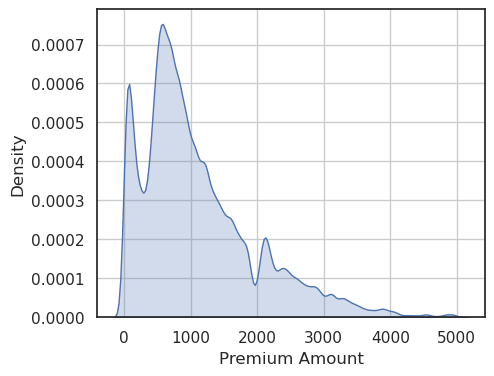

In [8]:
# set target
target = "Premium Amount"
ax = kdeplot(x=train_data[target])
train_data[target].describe()

In [9]:
# process data
def process_data(df: pd.DataFrame):
    new_df = df.copy()

    for col in ["Annual Income", "Health Score"]:
        new_df[col] = new_df[col].fillna(-1)

    policy_start = pd.to_datetime(new_df.pop("Policy Start Date"))

    new_df["Policy Start Year"] = policy_start.dt.year
    new_df["Policy Start Day of Week"] = policy_start.dt.day_of_week
    new_df["Policy Start Seconds"] = policy_start.astype(int) // 10**9

    month = policy_start.dt.month
    new_df["Policy Start Month Sin"] = np.sin(2 * np.pi * month / 12)
    new_df["Policy Start Month Cos"] = np.cos(2 * np.pi * month / 12)

    day = policy_start.dt.day
    new_df["Policy Start Day Sin"] = np.sin(2 * np.pi * day / 31)
    new_df["Policy Start Day Cos"] = np.cos(2 * np.pi * day / 31)

    return new_df


train_data = process_data(train_data)
test_data = process_data(test_data)


In [10]:
# set features
numerical_features = [
    "Age",
    "Annual Income",
    "Credit Score",
    "Health Score",
    "Insurance Duration",
    "Number of Dependents",
    "Policy Start Day Cos",
    "Policy Start Day of Week",
    "Policy Start Day Sin",
    "Policy Start Month Cos",
    "Policy Start Month Sin",
    "Policy Start Seconds",
    "Policy Start Year",
    "Previous Claims",
    "Vehicle Age",
]
ordinal_features = [
    "Customer Feedback",
    "Education Level",
    "Exercise Frequency",
    "Location",
    "Policy Type",
    "Smoking Status",
]
ordinal_categories = [
    ["Poor", "Average", "Good"],  # Customer Feedback
    ["High School", "Bachelor's", "Master's", "PhD"],  # Education Level
    ["Rarely", "Monthly", "Weekly", "Daily"],  # Exercise Frequency
    ["Rural", "Suburban", "Urban"],  # Location
    ["Premium", "Comprehensive", "Basic"],  # Policy Type
    ["No", "Yes"],  # Smoking Status
]
nominal_features = [
    "Gender",
    "Marital Status",
    "Occupation",
    "Property Type",
]

categorical_features = nominal_features + ordinal_features
features = numerical_features + categorical_features

plot_features = sorted(numerical_features + categorical_features)
corr_features = [target] + sorted(numerical_features + ordinal_features)


In [11]:
# use copies for exploratory analysis
train_data_encoded = train_data.copy()
test_data_encoded = test_data.copy()

# encode categorical features
feature_encoders = {}
for feature in categorical_features:
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1).fit(
        train_data[[feature]]
    )
    train_data_encoded[[feature]] = encoder.transform(train_data[[feature]])
    test_data_encoded[[feature]] = encoder.transform(test_data[[feature]])
    feature_encoders[feature] = encoder

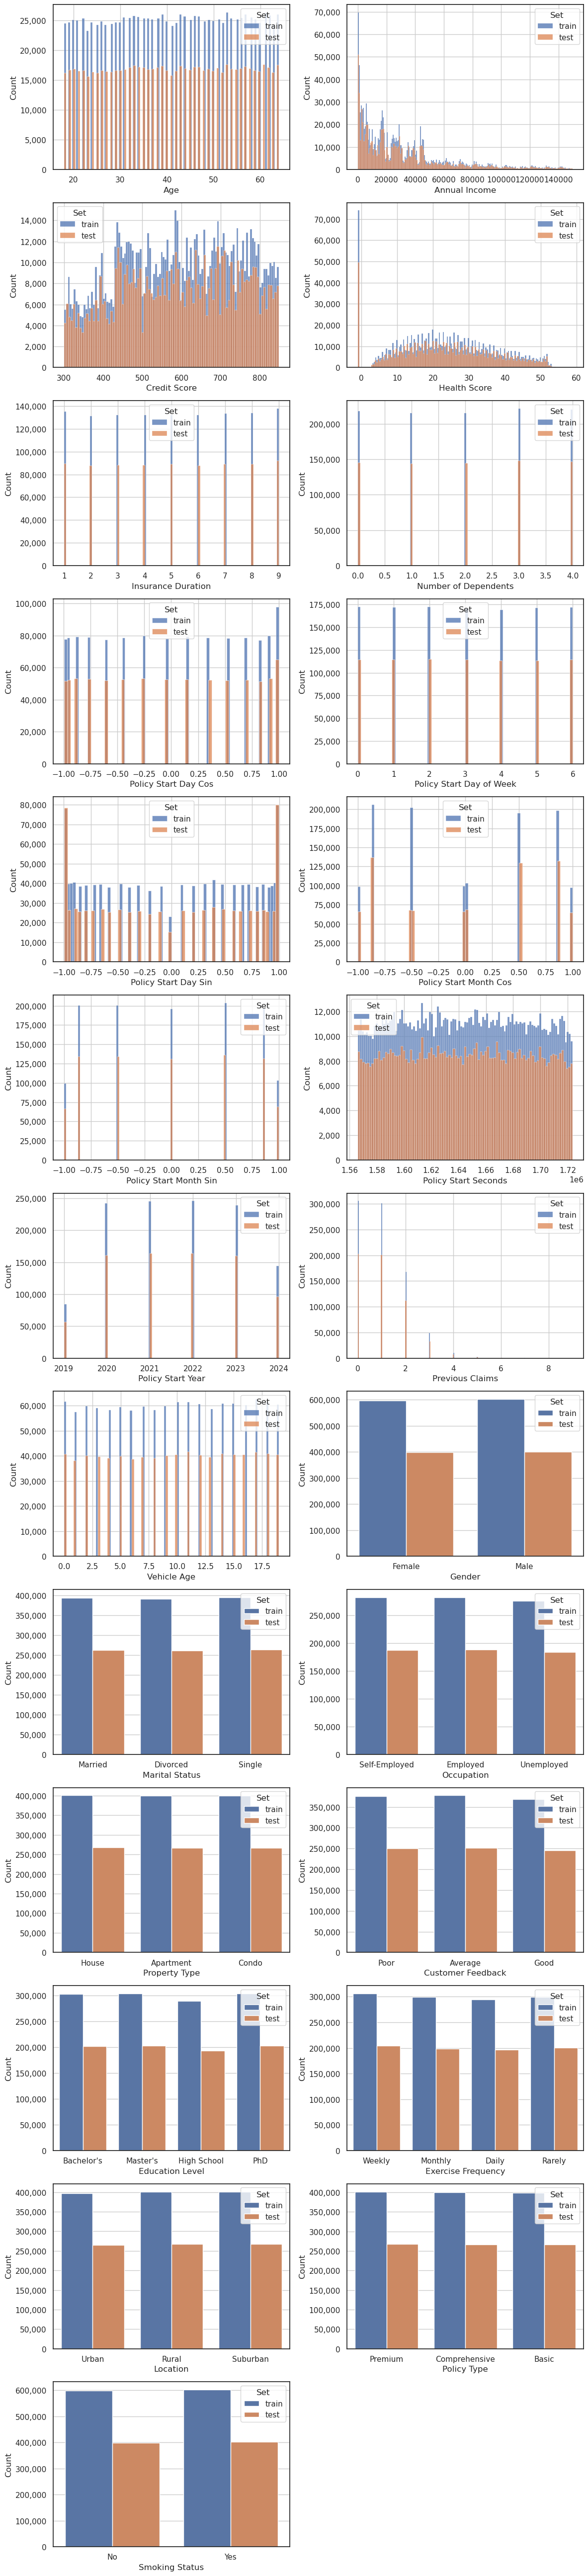

In [12]:
# plot features
unmerged_data = [train_data.assign(Set="train"), test_data.assign(Set="test")]
merged_data = pd.concat(unmerged_data, ignore_index=True, join="inner")
feature_groups = [(numerical_features, histplot), (categorical_features, countplot)]
fig, axes = subplots(feature_groups, data=merged_data, hue="Set")

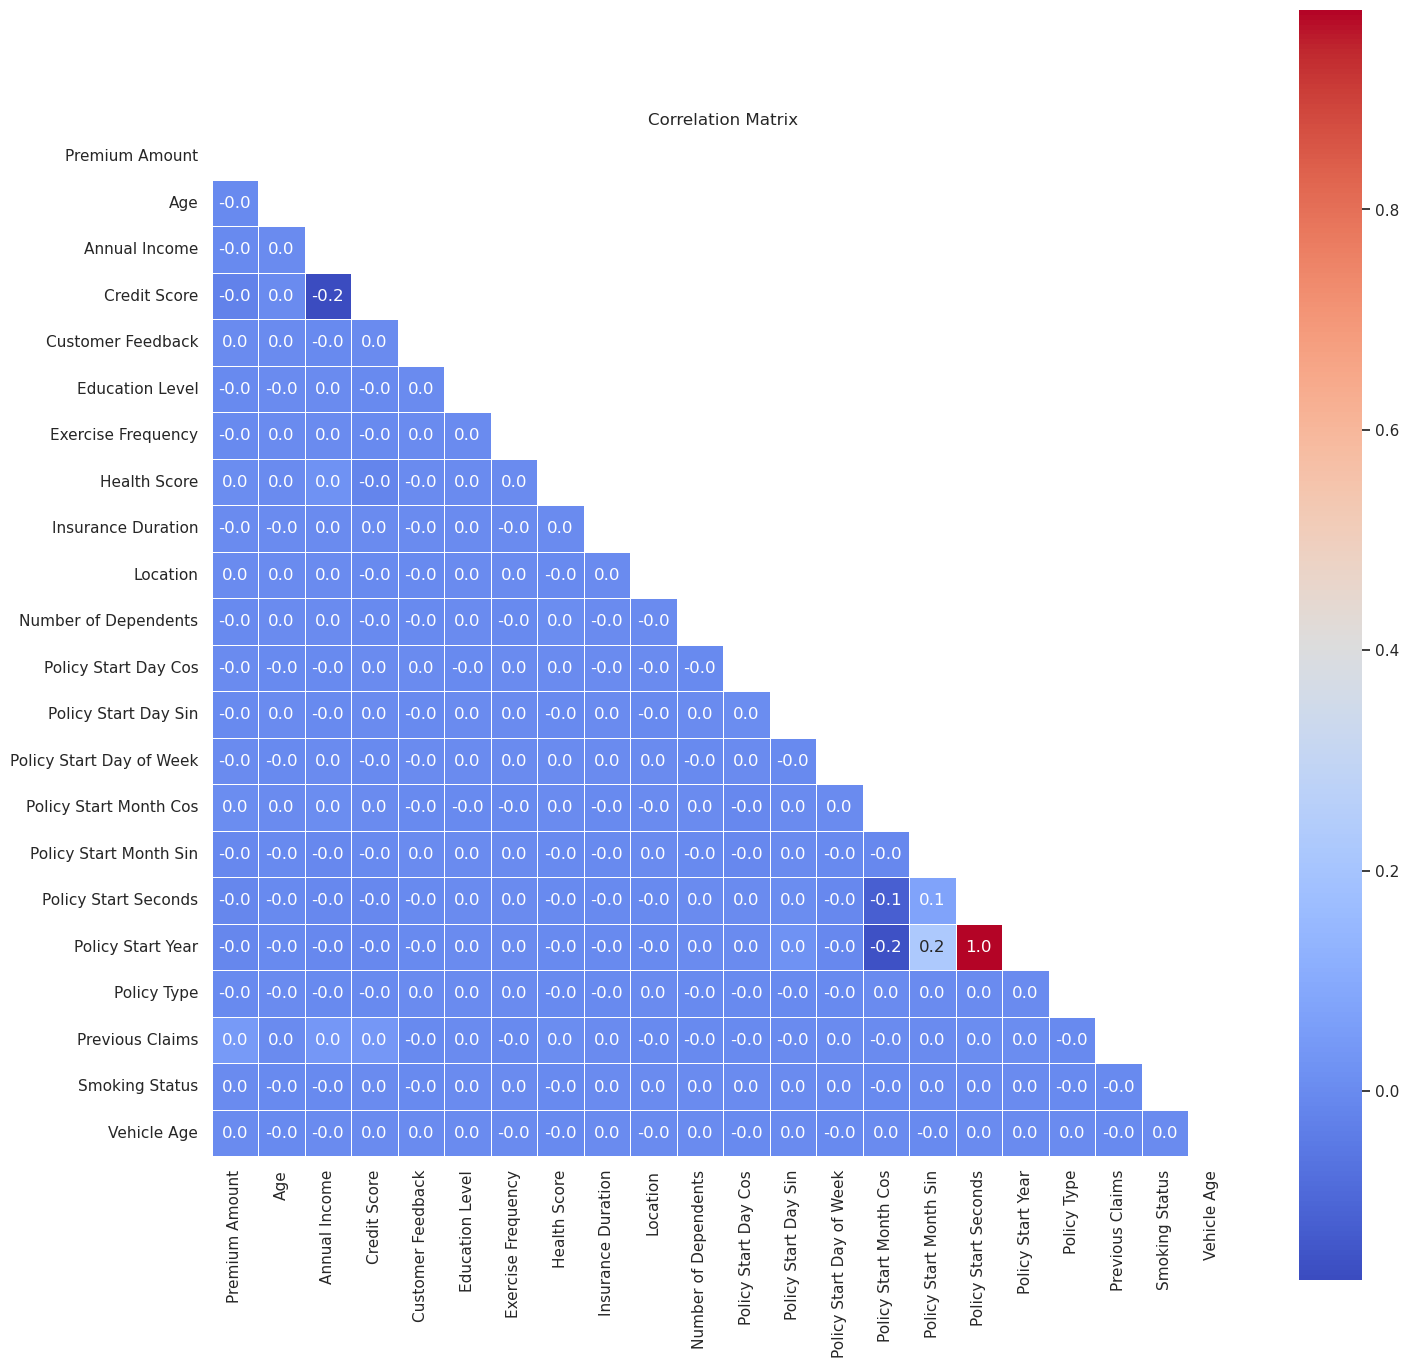

In [13]:
# plot correlations
corr = train_data_encoded[corr_features].corr()
ax = heatmap(data=corr, mask=np.triu(corr))
_ = ax.set_title("Correlation Matrix")

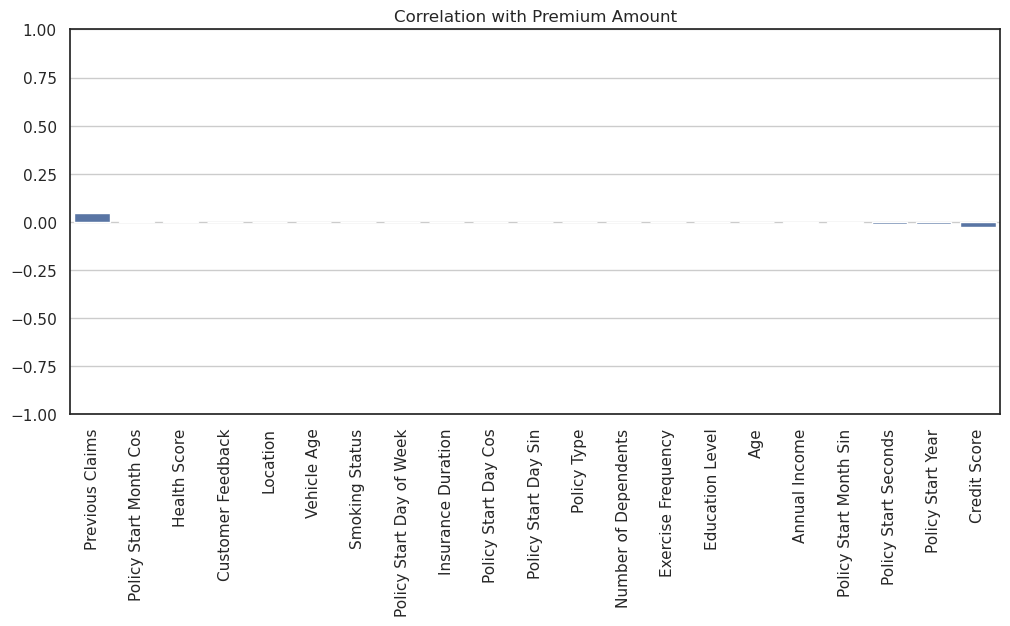

In [14]:
# plot target correlations
corrwith = corr[target].drop(target).sort_values(ascending=False)

ax = barplot(x=corrwith.index, y=corrwith.to_numpy(), rotation=90)
_ = ax.set_xlabel("")
_ = ax.set_ylim(-1, 1)
_ = ax.set_title(f"Correlation with {target}")

In [15]:
# validate that train and test sets have similar distributions
score = adversarial_score(data=merged_data, model=LGBMClassifier(verbose=-1))

threshold = 0.6
comp = "<" if score < threshold else ">="
message = "indistinguishable" if score < threshold else "distinguishable"
print(f"Score = {score:.2f} {comp} threshold = {threshold} → distributions {message}")

Score = 0.50 < threshold = 0.6 → distributions indistinguishable


# Data Preprocessing

In [16]:
# split data into training and test sets
X = train_data[features]
y = train_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# define preprocessing columns and steps
transformer_config = {
    "numerical": {
        "columns": numerical_features,
        "steps": [
            (
                "impute",
                SimpleImputer(strategy="median"),
            ),
            (
                "scale",
                RobustScaler(),
            ),
        ],
    },
    "nominal": {
        "columns": nominal_features,
        "steps": [
            (
                "impute",
                SimpleImputer(strategy="constant", fill_value="Unknown"),
            ),
            (
                "encode",
                OneHotEncoder(
                    sparse_output=False,
                    handle_unknown="ignore",
                ),
            ),
        ],
    },
    "ordinal": {
        "columns": ordinal_features,
        "steps": [
            (
                "impute",
                SimpleImputer(strategy="most_frequent"),
            ),
            (
                "encode",
                OrdinalEncoder(
                    categories=ordinal_categories,
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                ),
            ),
        ],
    },
}

In [18]:
# build preprocessor
transformers = []
for feature_type, config in transformer_config.items():
    columns = config["columns"]
    steps = config["steps"]
    feature_pipeline = Pipeline(steps=steps)
    transformers.append((feature_type, feature_pipeline, columns))

preprocessor = ColumnTransformer(transformers=transformers)
preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [19]:
# define scoring metrics
metrics = {
    "r2": {
        "func": r2_score,
    },
    "neg_mae": {
        "func": lambda y_true, y_pred: -mean_absolute_error(y_true, y_pred),
    },
    "neg_rmse": {
        "func": lambda y_true, y_pred: -root_mean_squared_error(y_true, y_pred),
    },
    "neg_rmsle": {
        "func": lambda y_true, y_pred: (
            -root_mean_squared_log_error(y_true, np.maximum(y_pred, 0))
        ),
    },
}

primary_metric = "neg_rmsle"
primary_scorer = make_scorer(metrics[primary_metric]["func"])

In [20]:
# create models and parameter spaces
models = {
    "ridge": {
        "model": Ridge(),
        "params": {
            "ridge__alpha": ("float", 1e-3, 1e3, {"log": True}),
        },
    },
    # too slow
    # "svr": {
    #     "model": SVR(),
    #     "params": {
    #         "svr__C": ("float", 1e-3, 1e3, {"log": True}),
    #         "svr__kernel": ("categorical", ["linear", "rbf", "poly"], None, {}),
    #         "svr__gamma": ("float", 1e-4, 1e0, {"log": True}),
    #         "svr__epsilon": ("float", 1e-3, 1.0, {"log": True}),
    #     },
    # },
    # too slow
    # "rf": {
    #     "model": RandomForestRegressor(random_state=42),
    #     "params": {
    #         "rf__n_estimators": ("int", 50, 500, {}),
    #         "rf__max_depth": ("int", 3, 20, {}),
    #         "rf__min_samples_split": ("int", 2, 20, {}),
    #         "rf__min_samples_leaf": ("int", 1, 10, {}),
    #         "rf__max_features": ("categorical", ["sqrt", "log2"], None, {}),
    #     },
    # },
    "decision": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "decision__max_depth": ("int", 3, 20, {}),
            "decision__min_samples_split": ("int", 2, 20, {}),
            "decision__min_samples_leaf": ("int", 1, 10, {}),
            "decision__criterion": (
                "categorical",
                ["squared_error", "absolute_error"],
                None,
                {},
            ),
        },
    },
    "xgb": {
        "model": XGBRegressor(random_state=42, enable_categorical=True),
        "params": {
            "xgb__n_estimators": ("int", 100, 1000, {}),
            "xgb__max_depth": ("int", 3, 10, {}),
            "xgb__learning_rate": ("float", 1e-3, 0.3, {"log": True}),
            "xgb__subsample": ("float", 0.5, 1.0, {}),
            "xgb__colsample_bytree": ("float", 0.5, 1.0, {}),
            "xgb__min_child_weight": ("int", 1, 10, {}),
            "xgb__gamma": ("float", 1e-8, 1.0, {"log": True}),
        },
    },
    "lgb": {
        "model": LGBMRegressor(random_state=42, verbose=-1),
        "params": {
            "lgb__n_estimators": ("int", 100, 1000, {}),
            "lgb__num_leaves": ("int", 31, 128, {}),
            "lgb__learning_rate": ("float", 1e-3, 0.3, {"log": True}),
            "lgb__subsample": ("float", 0.5, 1.0, {}),
            "lgb__colsample_bytree": ("float", 0.5, 1.0, {}),
            "lgb__min_child_samples": ("int", 20, 200, {}),
            "lgb__reg_alpha": ("float", 1e-8, 10.0, {"log": True}),
            "lgb__reg_lambda": ("float", 1e-8, 10.0, {"log": True}),
        },
    },
    # too slow
    # "gb": {
    #     "model": GradientBoostingRegressor(random_state=42),
    #     "params": {
    #         "gb__n_estimators": ("int", 50, 500, {}),
    #         "gb__learning_rate": ("float", 1e-3, 0.3, {"log": True}),
    #         "gb__max_depth": ("int", 3, 10, {}),
    #         "gb__subsample": ("float", 0.5, 1.0, {}),
    #         "gb__min_samples_split": ("int", 2, 20, {}),
    #         "gb__min_samples_leaf": ("int", 1, 10, {}),
    #     },
    # },
    "ada": {
        "model": AdaBoostRegressor(random_state=42),
        "params": {
            "ada__n_estimators": ("int", 50, 500, {}),
            "ada__learning_rate": ("float", 1e-3, 1.0, {"log": True}),
        },
    },
    "cat": {
        "model": CatBoostRegressor(
            random_state=42,
            verbose=0,
            bootstrap_type="Bernoulli",
            allow_writing_files=False,
        ),
        "params": {
            "cat__iterations": ("int", 100, 1000, {}),
            "cat__depth": ("int", 3, 10, {}),
            "cat__learning_rate": ("float", 1e-3, 0.3, {"log": True}),
            "cat__l2_leaf_reg": ("float", 1e-3, 10.0, {"log": True}),
            "cat__subsample": ("float", 0.5, 1.0, {}),
        },
    },
}

In [ ]:
# train all models with default parameters on X_train
train_results_list = []
train_times = {}
pipelines = {}

cv_train = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model_config in models.items():
    pipeline = Pipeline(
        [
            ("preprocessor", preprocessor),
            (model_name, model_config["model"]),
        ]
    )

    start_time = time.time()
    search = GridSearchCV(
        estimator=pipeline,
        param_grid={},
        cv=cv_train,
        scoring=primary_scorer,
        refit=True,
    )
    search.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    cv_scores = {primary_metric: search.cv_results_["mean_test_score"][0]}
    cv_scores["model"] = model_name

    pipelines[model_name] = search.best_estimator_
    train_times[model_name] = elapsed_time
    train_results_list.append(cv_scores)

train_results = pd.DataFrame(train_results_list).set_index("model")
train_results = train_results.sort_values(primary_metric, ascending=False)
best_model_name = str(train_results[primary_metric].idxmax())
display(train_results)

,neg_rmsle
model,
cat,-1.139
lgb,-1.139
xgb,-1.141
ridge,-1.168
ada,-1.276
decision,-1.514


In [22]:
# define objective function for tuning
def make_objective(model_name, cv, metric):
    def objective(trial):
        param_space = models[model_name]["params"]
        params = {}
        for param_name, spec in param_space.items():
            suggest_type, low, high, kwargs = spec
            if suggest_type == "int":
                params[param_name] = trial.suggest_int(param_name, low, high, **kwargs)
            elif suggest_type == "float":
                params[param_name] = trial.suggest_float(
                    param_name, low, high, **kwargs
                )
            elif suggest_type == "categorical":
                params[param_name] = trial.suggest_categorical(param_name, low)

        trial_pipeline = clone(pipelines[model_name])
        trial_pipeline.set_params(**params)

        scores = []
        for train_idx, val_idx in cv.split(X_train):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            trial_pipeline.fit(X_fold_train, y_fold_train)
            y_fold_pred = trial_pipeline.predict(X_fold_val)
            scores.append(metrics[metric]["func"](y_fold_val, y_fold_pred))

        return sum(scores) / len(scores)

    return objective

In [23]:
# tune best model on X_train
cv_tune = KFold(n_splits=5, shuffle=True, random_state=42)

tuned_start_time = time.time()

study = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(
    make_objective(best_model_name, cv_tune, primary_metric),
    n_trials=20,
    show_progress_bar=True,
)

tuned_elapsed_time = time.time() - tuned_start_time

tuned_model_name = f"{best_model_name}_tuned"
tuned_params = study.best_params

tuned_pipeline = clone(pipelines[best_model_name])
tuned_pipeline.set_params(**tuned_params)
tuned_pipeline.fit(X_train, y_train)

pipelines[tuned_model_name] = tuned_pipeline
train_times[tuned_model_name] = tuned_elapsed_time

tune_results = train_results.loc[[best_model_name]].copy()
tune_results.loc[tuned_model_name] = {primary_metric: study.best_value}
tune_results = tune_results.sort_values(primary_metric, ascending=False)
display(tune_results)
display(tuned_params)

Best trial: 18. Best value: -1.1381: 100%|██████████| 20/20 [23:33<00:00, 70.69s/it] 


,neg_rmsle
model,
lgb_tuned,-1.138
lgb,-1.139


{'lgb__n_estimators': 892,
 'lgb__num_leaves': 64,
 'lgb__learning_rate': 0.008604414495650395,
 'lgb__subsample': 0.5514679674687517,
 'lgb__colsample_bytree': 0.9995281609905557,
 'lgb__min_child_samples': 117,
 'lgb__reg_alpha': 9.863833155766363,
 'lgb__reg_lambda': 2.391147066701751e-06}

In [24]:
# evaluate all models on X_test
test_results_list = []

for model_name, pipeline in pipelines.items():
    y_test_pred = pipeline.predict(X_test)

    test_scores = {}
    for metric_name, metric_config in metrics.items():
        test_scores[metric_name] = metric_config["func"](y_test, y_test_pred)

    test_scores["model"] = model_name
    test_results_list.append(test_scores)

test_results = pd.DataFrame(test_results_list).set_index("model")
test_results["train_time"] = pd.Series(train_times)
test_results = test_results.sort_values(primary_metric, ascending=False)

display(test_results)

,r2,neg_mae,neg_rmse,neg_rmsle,train_time
model,,,,,
lgb_tuned,0.054,-637.540,-841.006,-1.140,1413.865
lgb,0.052,-638.544,-841.608,-1.140,27.987
cat,0.051,-638.288,-842.329,-1.141,168.493
xgb,0.047,-640.409,-843.990,-1.143,35.451
ridge,0.003,-667.303,-863.269,-1.169,17.915
ada,-0.113,-764.163,-911.915,-1.275,174.341
decision,-1.030,-894.812,-1231.793,-1.513,114.144


In [25]:
# retrain tuned model on X_train and X_test
final_model = clone(tuned_pipeline)
final_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

# Results

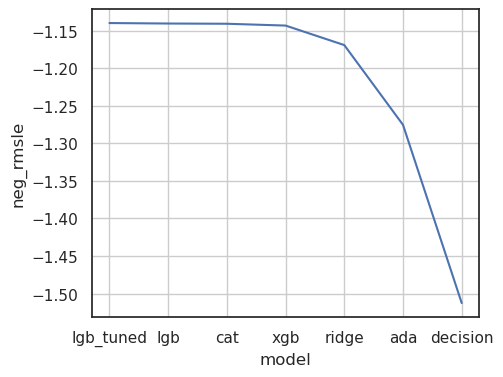

In [26]:
# plot initial results
ax = lineplot(data=test_results.reset_index(), x="model", y=primary_metric)

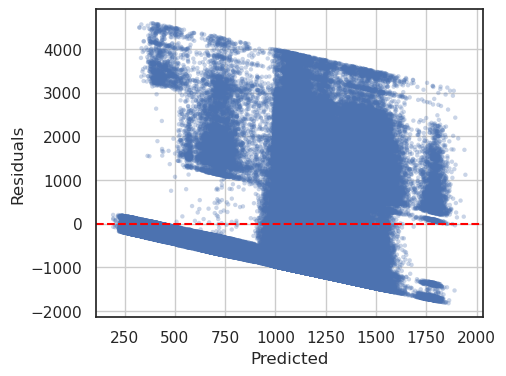

In [27]:
# plot residuals
y_pred = final_model.predict(X)
residuals = y.values - y_pred

ax = scatterplot(x=y_pred, y=residuals, alpha=0.3, s=10, edgecolor="none")
_ = ax.axhline(0, color="red", linestyle="--")
_ = ax.set_xlabel("Predicted")
_ = ax.set_ylabel("Residuals")

In [28]:
# make predictions
test_pred = final_model.predict(test_data)

# write to submissions file
sub_data[target] = test_pred
sub_data.to_csv("submission.csv", index=True, index_label=index_col)

pd.read_csv("submission.csv")

,id,Premium Amount
0,1200000,1196.679
1,1200001,1128.637
2,1200002,1085.844
3,1200003,1097.418
4,1200004,1039.007
...,...,...
799995,1999995,1224.211
799996,1999996,1411.067
799997,1999997,1119.577
799998,1999998,1125.420


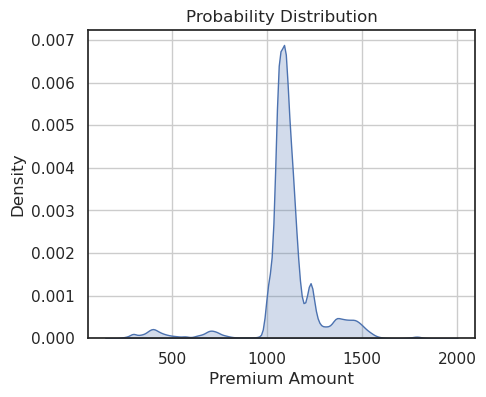

In [29]:
# plot predictions/probabilities
ax = kdeplot(x=sub_data[target])
_ = ax.set_title("Probability Distribution")